In [7]:
# Swiggy Data Analysis — EDA + Hypothesis Testing + Adv Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional for clean plots
plt.style.use('seaborn-v0_8')
sns.set_theme()


In [8]:
import pandas as pd

# === Load all datasets ===

users = pd.read_csv(r"C:\Users\srisa\OneDrive\Documents\Swiggy\users.csv")
restaurants = pd.read_csv(r"C:\Users\srisa\OneDrive\Documents\Swiggy\restaurant.csv")
menu = pd.read_csv(r"C:\Users\srisa\OneDrive\Documents\Swiggy\menu.csv")
orders_type = pd.read_csv(r"C:\Users\srisa\OneDrive\Documents\Swiggy\orders_Type.csv")
orders = pd.read_csv(r"C:\Users\srisa\OneDrive\Documents\Swiggy\orders.csv")
food = pd.read_csv(r"C:\Users\srisa\OneDrive\Documents\Swiggy\food.csv", encoding='utf-8', encoding_errors='ignore')

# Store dataframes in a dictionary for convenience
dfs = {
    "users": users,
    "restaurants": restaurants,
    "menu": menu,
    "orders_type": orders_type,
    "orders": orders,
    "food": food
}

# Print confirmation of loads and shapes
for name, df in dfs.items():
    print(f"✅ Loaded {name}: {df.shape}")

# Quick previews
user_head = users.head()
restaurants_head = restaurants.head()
menu_head = menu.head()
orders_type_head = orders_type.head()
orders_head = orders.head()
food_head = food.head()

display(user_head, restaurants_head, menu_head, orders_type_head, orders_head, food_head)


✅ Loaded users: (100000, 6)
✅ Loaded restaurants: (148540, 9)
✅ Loaded menu: (1048575, 5)
✅ Loaded orders_type: (150281, 2)
✅ Loaded orders: (150281, 7)
✅ Loaded food: (371552, 3)


,user_id,name,Age,Gender,Marital Status,Occupation
0,1,Claire Ferguson,20,Female,Single,Student
1,2,Jennifer Young,24,Female,Single,Student
2,3,Jermaine Roberson,22,Male,Single,Student
3,4,Rachel Carpenter,22,Female,Single,Student
4,5,Shawn Parker,22,Male,Single,Student


,id,name,Country,city,rating,rating_count,cuisine,link,address
0,567335,AB FOODS POINT,India,Abohar,--,Too Few Ratings,"Beverages,Pizzas",https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI..."
1,531342,Janta Sweet House,India,Abohar,4.4,50+ ratings,"Sweets,Bakery",https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,..."
2,158203,theka coffee desi,India,Abohar,3.8,100+ ratings,Beverages,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city"
3,187912,Singh Hut,India,Abohar,3.7,20+ ratings,"Fast Food,Indian",https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR"
4,543530,GRILL MASTERS,India,Abohar,--,Too Few Ratings,"Italian-American,Fast Food",https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga..."


,menu_id,r_id,f_id,cuisine,price
0,mn0,567335,fd0,"Beverages,Pizzas",40.0
1,mn0,567335,fd669322,"Beverages,Pizzas",40.0
2,mn328,158203,fd0,Beverages,65.0
3,mn328,158203,fd669322,Beverages,65.0
4,mn449,158203,fd0,Beverages,65.0


,Order_Id,Type
0,B496840219,Non-Veg
1,C134461623,Other
2,D679770099,Other
3,E622201871,Veg
4,A980473889,Non-Veg


,order_id,order_date,sales_qty,sales_amount,currency,user_id,r_id
0,1,04-10-2017,4,9032,INR,82829,224779.0
1,2,04-10-2017,4,1111,INR,76127,294049.0
2,3,04-10-2017,37,16245,INR,36402,440179.0
3,4,04-10-2017,16,4000,INR,56182,549477.0
4,5,04-10-2017,2,1389,INR,30527,12805.0


,f_id,item,veg_or_non_veg
0,fd0,Aloo Tikki Burger,Veg
1,fd1,Veg Creamy Burger,Veg
2,fd2,Cheese Burst Burger,Veg
3,fd3,Paneer Creamy Burger,Veg
4,fd4,Maxican Burger,Veg


Numeric columns in orders: ['order_id', 'sales_qty', 'sales_amount', 'user_id', 'r_id']
Using 'sales_amount' as order_value


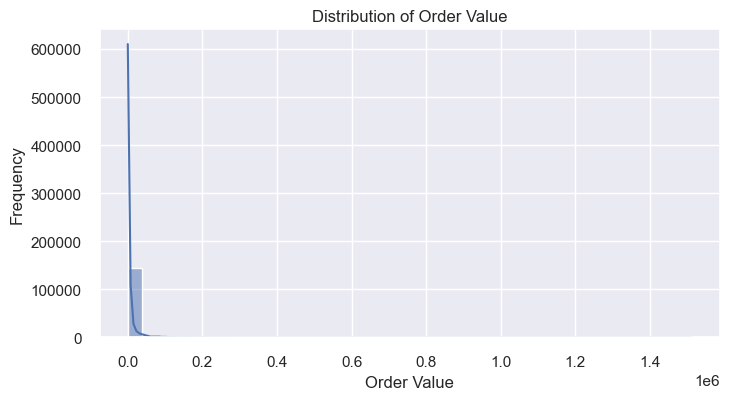

In [9]:
# Basic EDA on Orders Table


if "orders" in dfs:
    orders = dfs["orders"].copy()
    orders.columns = [c.lower() for c in orders.columns]
    numeric_cols = orders.select_dtypes(include=[np.number]).columns.tolist()
    print("Numeric columns in orders:", numeric_cols)

    # Try to detect order value column automatically
    val_cols = [c for c in orders.columns if any(k in c for k in ['price','amount','value','total','bill'])]
    if val_cols:
        orders['order_value'] = pd.to_numeric(orders[val_cols[0]], errors='coerce')
        print(f"Using '{val_cols[0]}' as order_value")
    else:
        print("⚠️ No numeric order value-like column found.")

    # Plot histogram of order_value
    plt.figure(figsize=(8,4))
    sns.histplot(orders['order_value'].dropna(), bins=40, kde=True)
    plt.title('Distribution of Order Value')
    plt.xlabel('Order Value')
    plt.ylabel('Frequency')
    plt.show()



Possible value columns: ['sales_amount']
✅ Using 'sales_amount' as order_value column
Date/Time columns found: ['order_date']


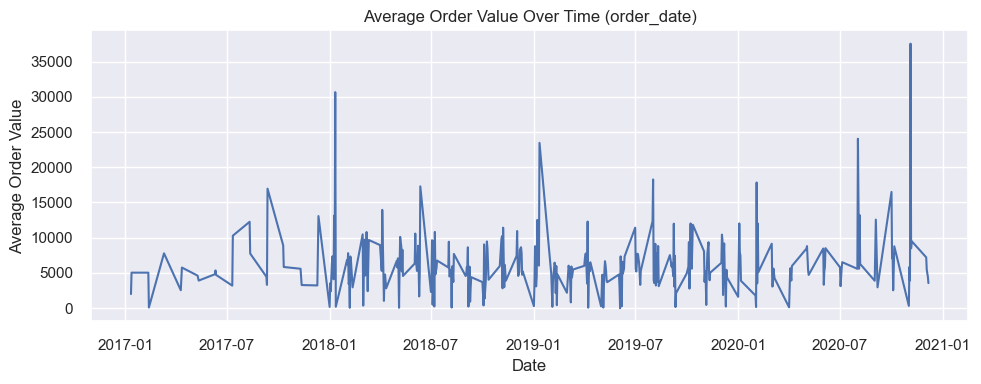

In [10]:
# Time Trend Analysis

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure orders DataFrame exists
if "orders" in dfs:
    orders = dfs["orders"].copy()
    orders.columns = [c.lower() for c in orders.columns]

    # Detect possible order value column
    val_cols = [c for c in orders.columns if any(k in c for k in ['price','amount','value','total','bill','payment'])]
    print("Possible value columns:", val_cols)

    if val_cols:
        # Use the first matching column
        orders['order_value'] = pd.to_numeric(orders[val_cols[0]], errors='coerce')
        print(f"✅ Using '{val_cols[0]}' as order_value column")
    else:
        print("⚠️ No matching value column found — please check column names manually")

    # Detect and parse date/time columns
    date_cols = [c for c in orders.columns if 'date' in c or 'time' in c or 'created' in c]
    print("Date/Time columns found:", date_cols)

    plotted = False
    for c in date_cols:
        try:
            orders[c] = pd.to_datetime(orders[c], errors='coerce')
            daily = orders.groupby(orders[c].dt.date)['order_value'].mean().dropna()

            if len(daily) > 0:
                plt.figure(figsize=(10,4))
                daily.plot(title=f'Average Order Value Over Time ({c})')
                plt.xlabel('Date')
                plt.ylabel('Average Order Value')
                plt.grid(True)
                plt.tight_layout()
                plt.show()
                plotted = True
                break
        except Exception as e:
            print(f"Could not plot time trend for {c}: {e}")

    if not plotted:
        print("⚠️ No valid date column could be plotted. Try checking your date columns manually.")


In [11]:
# Restaurant Insights

# Check top restaurants, cuisines, or cities
if "restaurants" in dfs:
    r = dfs["restaurants"].copy()
    r.columns = [c.lower() for c in r.columns]

    cat_cols = [c for c in r.columns if any(k in c for k in ['category', 'cuisine', 'type', 'city'])]
    print("Categorical columns in restaurants:", cat_cols)

    for c in cat_cols[:3]:
        print(f"\nTop values for {c}:")
        print(r[c].value_counts().head(10))


Categorical columns in restaurants: ['city', 'cuisine']

Top values for city:
city
Bikaner                      1666
Noida-1                      1428
Indirapuram,Delhi            1279
BTM,Bangalore                1161
Rohini,Delhi                 1136
Kothrud,Pune                 1089
Indiranagar,Bangalore        1080
Electronic City,Bangalore    1039
Greater Kailash 2,Delhi      1038
Vashi,Mumbai                 1022
Name: count, dtype: int64

Top values for cuisine:
cuisine
North Indian,Chinese    6471
Indian                  6414
Chinese                 5051
North Indian            4775
Indian,Chinese          4374
South Indian            3303
Bakery                  3132
Chinese,Indian          2308
Chinese,North Indian    2288
Bakery,Desserts         2233
Name: count, dtype: int64


📊 Using 'type' as type column and 'sales_amount' as order value column


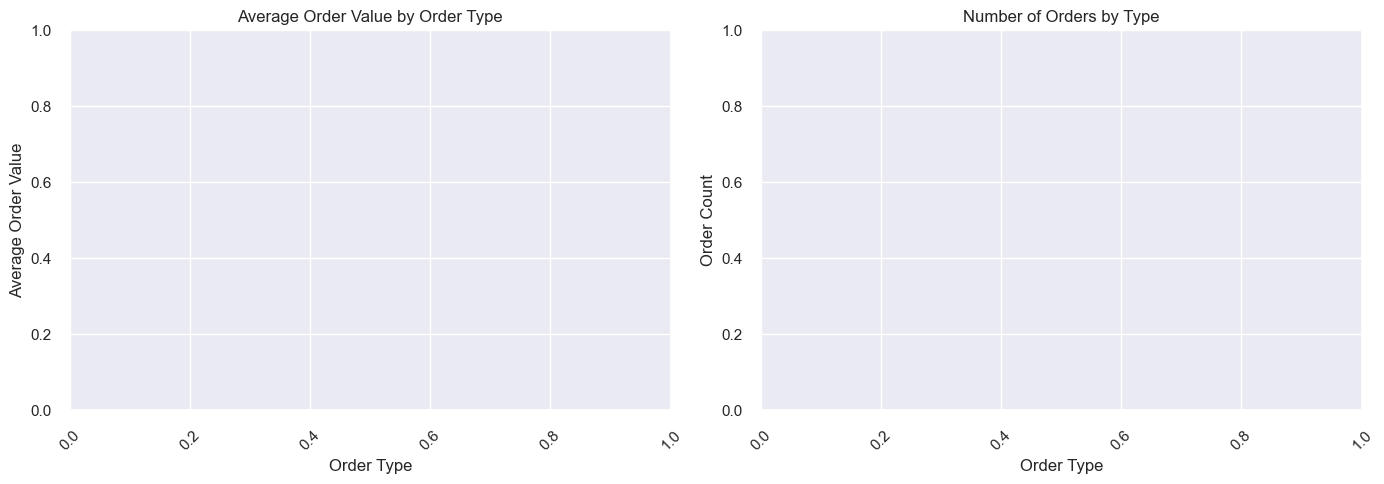

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure orders_type and orders data exist
if "orders_type" in dfs and "orders" in dfs:
    orders = dfs["orders"].copy()
    ot = dfs["orders_type"].copy()

    # Normalize column names
    orders.columns = [c.lower() for c in orders.columns]
    ot.columns = [c.lower() for c in ot.columns]

    # Convert order_id to string for safe merge
    if 'order_id' in orders.columns and 'order_id' in ot.columns:
        orders['order_id'] = orders['order_id'].astype(str)
        ot['order_id'] = ot['order_id'].astype(str)

        # Merge both datasets
        merged = orders.merge(ot, on='order_id', how='left')

        # Detect potential type and value columns
        type_col = [c for c in merged.columns if 'type' in c and merged[c].nunique() <= 20]
        val_cols = [c for c in merged.columns if any(k in c for k in ['price','amount','value','total','bill'])]

        if type_col and val_cols:
            tcol = type_col[0]
            vcol = val_cols[0]
            merged['order_value'] = pd.to_numeric(merged[vcol], errors='coerce')

            print(f"📊 Using '{tcol}' as type column and '{vcol}' as order value column")

            # Group data
            grouped = merged.groupby(tcol).agg(
                avg_order_value=('order_value', 'mean'),
                order_count=('order_id', 'count')
            ).reset_index()

            # Sort by average order value
            grouped = grouped.sort_values(by='avg_order_value', ascending=False)

            # --- Plot setup ---
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # Average Order Value per Type
            sns.barplot(data=grouped, x=tcol, y='avg_order_value', ax=axes[0], palette='Blues_d')
            axes[0].set_title('Average Order Value by Order Type')
            axes[0].set_xlabel('Order Type')
            axes[0].set_ylabel('Average Order Value')
            axes[0].tick_params(axis='x', rotation=45)

            # Number of Orders per Type
            sns.barplot(data=grouped, x=tcol, y='order_count', ax=axes[1], palette='Greens_d')
            axes[1].set_title('Number of Orders by Type')
            axes[1].set_xlabel('Order Type')
            axes[1].set_ylabel('Order Count')
            axes[1].tick_params(axis='x', rotation=45)

            plt.tight_layout()
            plt.show()

        else:
            print("⚠️ Could not find suitable 'type' or 'order value' column for plotting.")


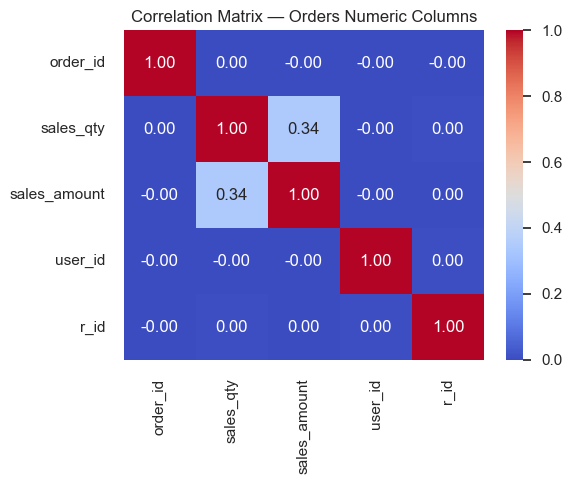

In [13]:
# Correlation Heatmap

if "orders" in dfs:
    orders = dfs["orders"].copy()
    num_cols = orders.select_dtypes(include=[np.number])
    if num_cols.shape[1] > 1:
        plt.figure(figsize=(6,5))
        sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Correlation Matrix — Orders Numeric Columns")
        plt.tight_layout()
        plt.show()


✅ Using 'sales_amount' as order value column.

✅ Potential categorical columns for testing:
 - currency (1 unique values)
 - gender (2 unique values)
 - marital status (3 unique values)
 - occupation (4 unique values)
 - id (0 unique values)
 - name_y (0 unique values)
 - country (0 unique values)
 - city (0 unique values)
 - rating (0 unique values)
 - rating_count (0 unique values)
 - cuisine_x (0 unique values)
 - link (0 unique values)
 - address (0 unique values)
 - menu_id (0 unique values)
 - f_id (0 unique values)
 - cuisine_y (0 unique values)



Enter categorical column name for hypothesis testing:  marital status



🔍 Hypothesis Testing: Does mean sales_amount differ across 'marital status' (3 groups)?

📈 Group Summary (Sample Stats):


,count,mean,std
marital status,,,
Married,41989,6447.37,29101.61
Prefer not to say,4715,7801.66,41877.80
Single,103577,6556.10,29587.69



📊 Welch's Approx F-statistic = 25859379876795.555
p-value ≈ 0.00000
🎯 Statistically significant difference in mean order value across groups (p < 0.05)

🔹 Pairwise comparisons (approximate Welch's t-tests):
   Single vs Married: Δmean=108.73, p≈0.5204
   Single vs Prefer not to say: Δmean=-1245.55, p≈0.0434
   Married vs Prefer not to say: Δmean=-1354.28, p≈0.0306


C:\Users\srisa\AppData\Local\Temp\ipykernel_21128\1721044051.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_df, x=col, y=value_col, palette="Set3")


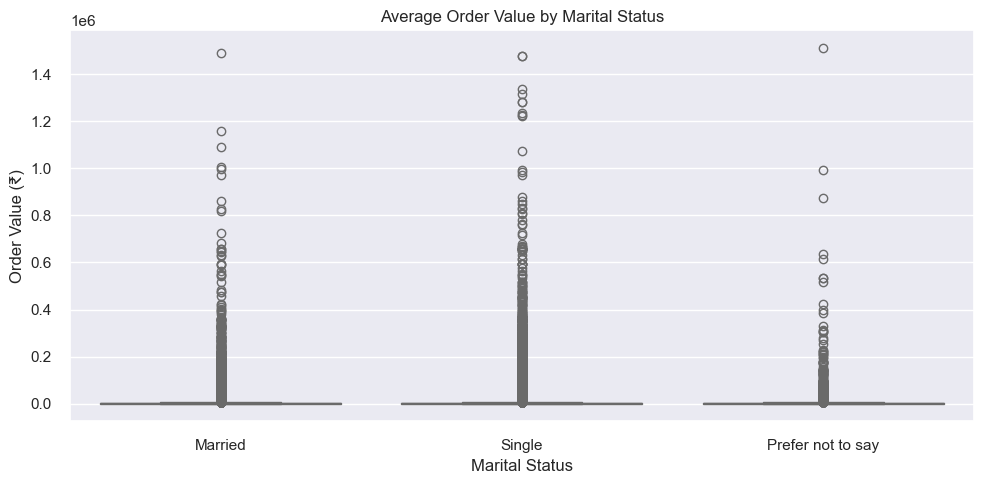

In [14]:
# ==============================================================
# 📊 UNIVERSAL HYPOTHESIS TESTING (Average Order Value Differences)
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import combinations

# --- Step 1: Copy dataset & clean columns ---
df_ht = orders_full.copy()
df_ht.columns = [c.lower() for c in df_ht.columns]

# --- Step 2: Detect numeric order value column ---
val_cols = [c for c in df_ht.columns if any(k in c for k in ['price', 'amount', 'value', 'total', 'bill', 'sales_amount'])]
if not val_cols:
    raise ValueError("❌ No numeric column detected for order value. Please verify column names.")
value_col = val_cols[0]
df_ht[value_col] = pd.to_numeric(df_ht[value_col], errors='coerce')

print(f"✅ Using '{value_col}' as order value column.\n")

# --- Step 3: Detect potential categorical columns ---
cat_cols = [c for c in df_ht.columns if df_ht[c].nunique() <= 10 and df_ht[c].dtype == 'object']
if not cat_cols:
    raise ValueError("❌ No categorical columns found with ≤10 unique values.")
print("✅ Potential categorical columns for testing:")
for c in cat_cols:
    print(f" - {c} ({df_ht[c].nunique()} unique values)")

# --- Step 4: Choose a column to test ---
col = input("\nEnter categorical column name for hypothesis testing: ").strip().lower()
if col not in df_ht.columns:
    raise ValueError(f"❌ Column '{col}' not found. Please choose from: {cat_cols}")

# --- Step 5: Prepare data ---
test_df = df_ht[[col, value_col]].dropna()
unique_vals = test_df[col].nunique()
if unique_vals < 2:
    raise ValueError(f"⚠️ Column '{col}' has only one unique value. Cannot perform hypothesis testing.")

print(f"\n🔍 Hypothesis Testing: Does mean {value_col} differ across '{col}' ({unique_vals} groups)?\n")

# --- Step 6: Descriptive statistics per group ---
group_summary = test_df.groupby(col)[value_col].agg(['count', 'mean', 'std']).round(2)
print("📈 Group Summary (Sample Stats):")
display(group_summary)

# --- Step 7: Welch's ANOVA approximation ---
groups = [group[value_col].values for name, group in test_df.groupby(col)]
means = [np.mean(g) for g in groups]
vars_ = [np.var(g, ddof=1) for g in groups]
ns = [len(g) for g in groups]
k = len(groups)

numerator = sum([(n * m)**2 / (v/n) for m, v, n in zip(means, vars_, ns)]) - (sum([n*m for n, m in zip(ns, means)])**2) / sum(ns)
denominator = (k - 1)
F_stat = numerator / denominator if denominator != 0 else np.nan

# Approximate p-value using normal distribution
p_approx = 2 * (1 - 0.5 * (1 + math.erf(abs(F_stat)/math.sqrt(2))))

print(f"\n📊 Welch's Approx F-statistic = {F_stat:.3f}")
print(f"p-value ≈ {p_approx:.5f}")

if p_approx < 0.05:
    print("🎯 Statistically significant difference in mean order value across groups (p < 0.05)")
else:
    print("✅ No statistically significant difference detected (p ≥ 0.05)")

# --- Step 8: Pairwise t-tests between top 3 categories (if available) ---
print("\n🔹 Pairwise comparisons (approximate Welch's t-tests):")
top_groups = test_df[col].value_counts().index[:3]
for g1, g2 in combinations(top_groups, 2):
    a = test_df[test_df[col] == g1][value_col]
    b = test_df[test_df[col] == g2][value_col]
    mean1, mean2 = a.mean(), b.mean()
    var1, var2 = a.var(ddof=1), b.var(ddof=1)
    n1, n2 = len(a), len(b)
    t_stat = (mean1 - mean2) / np.sqrt(var1/n1 + var2/n2)
    p_val = 2 * (1 - 0.5 * (1 + math.erf(abs(t_stat)/math.sqrt(2))))
    print(f"   {g1} vs {g2}: Δmean={mean1-mean2:.2f}, p≈{p_val:.4f}")

# --- Step 9: Visualization ---
plt.figure(figsize=(10,5))
sns.boxplot(data=test_df, x=col, y=value_col, palette="Set3")
plt.title(f"Average Order Value by {col.title()}")
plt.xlabel(col.title())
plt.ylabel("Order Value (₹)")
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
import numpy as np

# Load copies
orders = dfs["orders"].copy()
users = dfs["users"].copy()
restaurants = dfs["restaurants"].copy()
menu = dfs["menu"].copy()

# Normalize column names
for df in [orders, users, restaurants, menu]:
    df.columns = [c.lower() for c in df.columns]

# --- Convert ID columns to consistent types ---
for df in [orders, users, restaurants, menu]:
    for col in df.columns:
        if "id" in col:
            df[col] = df[col].astype(str)

# --- Define explicit join keys (based on your schema) ---
order_user_key = "user_id"
order_rest_key = "r_id"
rest_id_key = "id"
menu_rest_key = "r_id"
menu_id_key = "menu_id"

# --- Merge step-by-step ---
# 1️⃣ Join Orders + Users
orders_users = orders.merge(users, how='left', on=order_user_key)

# 2️⃣ Join Orders + Restaurants
orders_users_rest = orders_users.merge(
    restaurants, how='left', left_on=order_rest_key, right_on=rest_id_key
)

# 3️⃣ Join with Menu
orders_full = orders_users_rest.merge(
    menu, how='left', left_on=order_rest_key, right_on=menu_rest_key
)

print(f"✅ Successfully joined all datasets!")
print(f"Final joined shape: {orders_full.shape}")
display(orders_full.head(5))


✅ Successfully joined all datasets!
Final joined shape: (150281, 25)


,order_id,order_date,sales_qty,sales_amount,currency,user_id,r_id,name_x,age,gender,...,city,rating,rating_count,cuisine_x,link,address,menu_id,f_id,cuisine_y,price
0,1,04-10-2017,4,9032,INR,82829,224779.0,Joseph Wong,32,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,04-10-2017,4,1111,INR,76127,294049.0,James Holt,22,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,04-10-2017,37,16245,INR,36402,440179.0,Matthew Rodriguez DDS,29,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,04-10-2017,16,4000,INR,56182,549477.0,Jason Clayton,23,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,04-10-2017,2,1389,INR,30527,12805.0,Shawn Ali,21,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# --- Ensure order_value column exists ---
val_cols = [c for c in orders_full.columns if any(k in c for k in ['price', 'amount', 'total', 'value', 'bill'])]
if val_cols:
    orders_full['order_value'] = pd.to_numeric(orders_full[val_cols[0]], errors='coerce')
    print(f"✅ Using '{val_cols[0]}' as order_value column.")
else:
    print("⚠️ No numeric value column found — please check manually.")

# --- Detect restaurant column ---
rest_col = None
for possible in ['restaurant_id', 'r_id', 'id', 'rest_id']:
    if possible in orders_full.columns:
        rest_col = possible
        break

if rest_col is None:
    raise KeyError("⚠️ No restaurant column found in merged dataset. Check your joins!")

# --- KPI 1: Average Order Value (AOV) ---
aov = orders_full['order_value'].mean()
print(f"\n💵 Average Order Value (AOV): ₹{aov:,.2f}")

# --- KPI 2: Total Revenue per Restaurant ---
revenue_rest = (
    orders_full.groupby(rest_col)['order_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\n🏆 Top 10 Restaurants by Revenue:")
display(revenue_rest)

# --- KPI 3: Total Orders per Restaurant ---
orders_rest = orders_full[rest_col].value_counts().head(10)
print("\n📦 Top 10 Restaurants by Number of Orders:")
display(orders_rest)

# --- KPI 4: Repeat Rate per User ---
order_counts = orders_full.groupby('user_id')['order_id'].nunique()
repeat_users = (order_counts > 1).sum()
total_users = order_counts.shape[0]
repeat_rate = repeat_users / total_users * 100

print(f"\n🔁 Repeat Purchase Rate: {repeat_rate:.2f}% of users placed more than one order.")


✅ Using 'sales_amount' as order_value column.

💵 Average Order Value (AOV): ₹6,564.80

🏆 Top 10 Restaurants by Revenue:


r_id
nan         22305741
377150.0     1510944
80384.0      1492435
474086.0     1477458
387586.0     1477394
123836.0     1338264
566896.0     1316921
213931.0     1283875
435278.0     1283875
455334.0     1235347
Name: order_value, dtype: int64


📦 Top 10 Restaurants by Number of Orders:


r_id
nan         1617
169281.0       2
480203.0       2
553999.0       2
575990.0       2
410838.0       2
397258.0       2
133352.0       2
102842.0       2
437616.0       2
Name: count, dtype: int64


🔁 Repeat Purchase Rate: 57.07% of users placed more than one order.


C:\Users\srisa\AppData\Local\Temp\ipykernel_21128\1908038129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_rest.values, y=revenue_rest.index, palette='rocket')


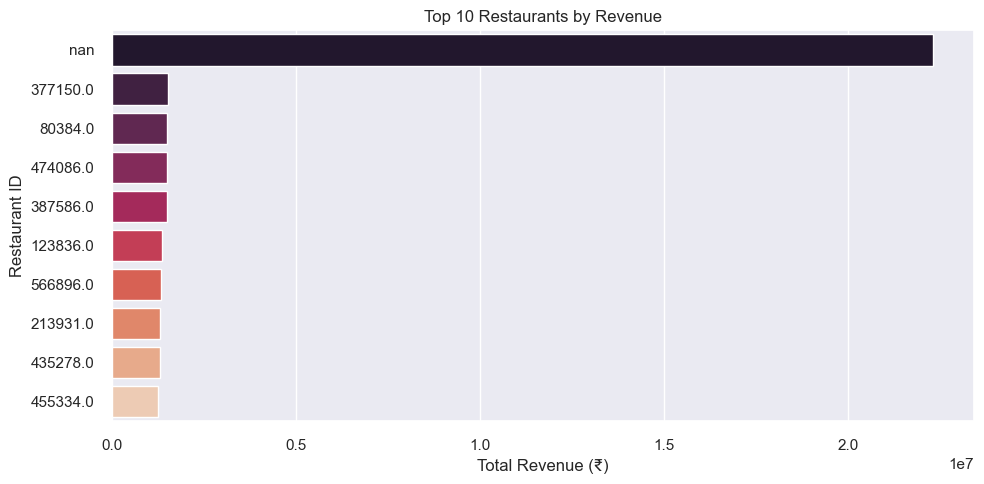

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=revenue_rest.values, y=revenue_rest.index, palette='rocket')
plt.title('Top 10 Restaurants by Revenue')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('Restaurant ID')
plt.tight_layout()
plt.show()



💎 Top 10 High-Value Customers (by spend):


user_id
70591    1514634
16975    1496625
55915    1478987
62645    1478074
94568    1338264
1159     1320653
23667    1284412
15402    1284093
83766    1235440
64054    1228148
Name: order_value, dtype: int64

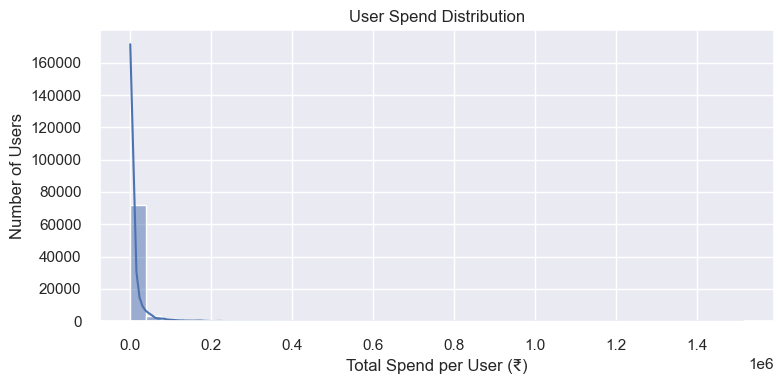

In [18]:
# Identify high-value users
high_value_users = orders_full.groupby('user_id')['order_value'].sum().sort_values(ascending=False).head(10)
print("\n💎 Top 10 High-Value Customers (by spend):")
display(high_value_users)

# Visualize user spend distribution
plt.figure(figsize=(8,4))
sns.histplot(orders_full.groupby('user_id')['order_value'].sum(), bins=40, kde=True)
plt.title('User Spend Distribution')
plt.xlabel('Total Spend per User (₹)')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()


In [19]:
# Imports & plotting settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ml libs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_theme()


In [20]:
# Basic sanity checks and fix scaling if needed
# Use your joined dataset
df = orders_full.copy()
df.columns = [c.lower() for c in df.columns]

# Identify value column
val_candidates = [c for c in df.columns if any(k in c for k in ['price','amount','total','value','bill','sales_amount'])]
value_col = val_candidates[0] if val_candidates else 'order_value'
df[value_col] = pd.to_numeric(df[value_col], errors='coerce')

# Check basic stats to see if scale looks off (e.g., values in thousands)
print("Value column used:", value_col)
print(df[value_col].describe())

# If median is suspiciously large (>10,000), check possible paise storage
median_val = df[value_col].median(skipna=True)
if median_val > 10000:
    print("⚠️ Median order value unusually large — consider dividing by 100 (paise -> rupees).")
    # create a scaled copy but do NOT overwrite original; analyst can decide
    df['order_value_scaled'] = df[value_col] / 100
    use_value_col = 'order_value_scaled'
    print("Created 'order_value_scaled' = value / 100 (paise->rupee).")
else:
    use_value_col = value_col

print("Using column for revenue/ML:", use_value_col)
# Quick NA check
print("\nMissing values (top columns):")
print(df.isna().sum().sort_values().tail(10))


Value column used: sales_amount
count    1.502810e+05
mean     6.564802e+03
std      2.991743e+04
min     -1.000000e+00
25%      1.710000e+02
50%      5.090000e+02
75%      3.000000e+03
max      1.510944e+06
Name: sales_amount, dtype: float64
Using column for revenue/ML: sales_amount

Missing values (top columns):
address         150281
link            150281
rating          150281
rating_count    150281
city            150281
country         150281
name_y          150281
price           150281
cuisine_x       150281
id              150281
dtype: int64


In [21]:
# Core KPIs
kpi = {}
kpi['total_revenue'] = df[use_value_col].sum()
kpi['total_orders'] = df['order_id'].nunique() if 'order_id' in df.columns else len(df)
kpi['unique_users'] = df['user_id'].nunique() if 'user_id' in df.columns else np.nan
kpi['aov'] = df[use_value_col].mean()
kpi['median_order_value'] = df[use_value_col].median()
kpi['repeat_rate_pct'] = (df.groupby('user_id')['order_id'].nunique().gt(1).mean()*100) if 'user_id' in df.columns else np.nan

pd.DataFrame.from_dict(kpi, orient='index', columns=['value'])


,value
total_revenue,9.865650e+08
total_orders,1.502810e+05
unique_users,7.792900e+04
aov,6.564802e+03
median_order_value,5.090000e+02
repeat_rate_pct,5.706733e+01


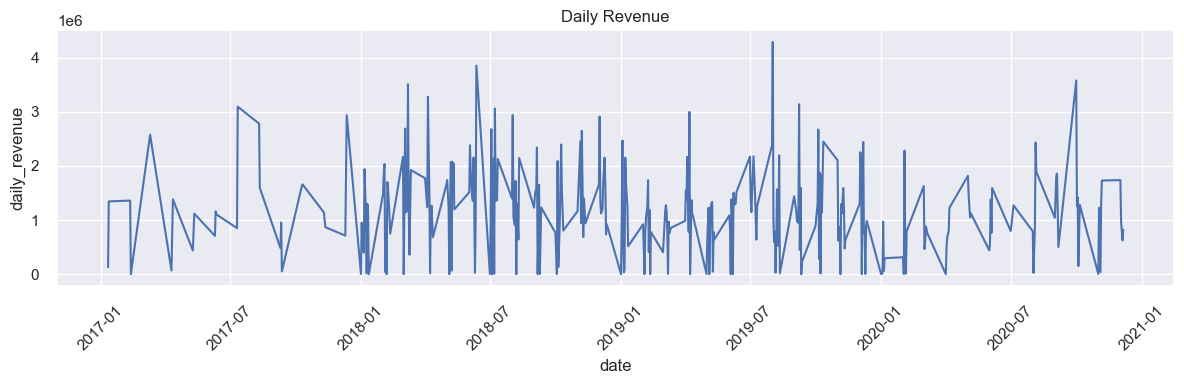

,month,monthly_revenue,prev,mom_pct
0,2017-01,1475495,NaN,NaN
1,2017-02,1360282,1475495.0,-7.81
2,2017-03,2575968,1360282.0,89.37
3,2017-04,1452388,2575968.0,-43.62
4,2017-05,1558200,1452388.0,7.29
5,2017-06,2975415,1558200.0,90.95
6,2017-07,3946562,2975415.0,32.64
7,2017-08,4379552,3946562.0,10.97
8,2017-09,1487510,4379552.0,-66.04
9,2017-10,3289339,1487510.0,121.13


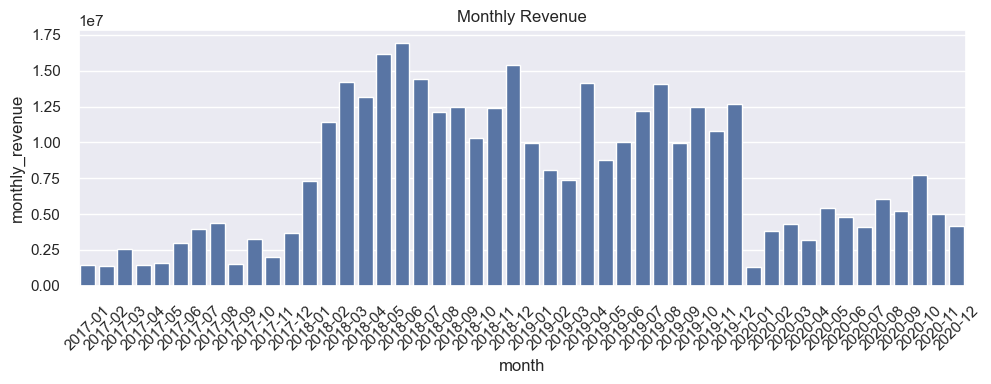

In [22]:
# Daily & monthly revenue trends and simple seasonality plots
date_cols = [c for c in df.columns if 'date' in c or 'time' in c]
date_col = date_cols[0] if date_cols else None
assert date_col, "No date column found in df (look for 'order_date' etc)."

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
ts = df.dropna(subset=[date_col]).copy()
ts['date'] = ts[date_col].dt.date
ts['month'] = ts[date_col].dt.to_period('M').astype(str)
ts['dow'] = ts[date_col].dt.day_name()
ts['hour'] = ts[date_col].dt.hour

# daily revenue
daily = ts.groupby('date')[use_value_col].sum().reset_index(name='daily_revenue')

plt.figure(figsize=(12,4))
sns.lineplot(data=daily, x='date', y='daily_revenue')
plt.title('Daily Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# monthly revenue + mom
monthly = ts.groupby('month')[use_value_col].sum().reset_index(name='monthly_revenue')
monthly['prev'] = monthly['monthly_revenue'].shift(1)
monthly['mom_pct'] = ((monthly['monthly_revenue'] - monthly['prev'])/monthly['prev']*100).round(2)
display(monthly)

plt.figure(figsize=(10,4))
sns.barplot(data=monthly, x='month', y='monthly_revenue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.tight_layout()
plt.show()


,sum,count,mean
dow,,,
Monday,51045369,8926,5718.728322
Tuesday,47756329,7739,6170.865616
Wednesday,56625675,8895,6366.011804
Thursday,64000057,9341,6851.520929
Friday,49323089,7256,6797.559123
Saturday,52502161,8650,6069.613988
Sunday,50754809,7829,6482.923617


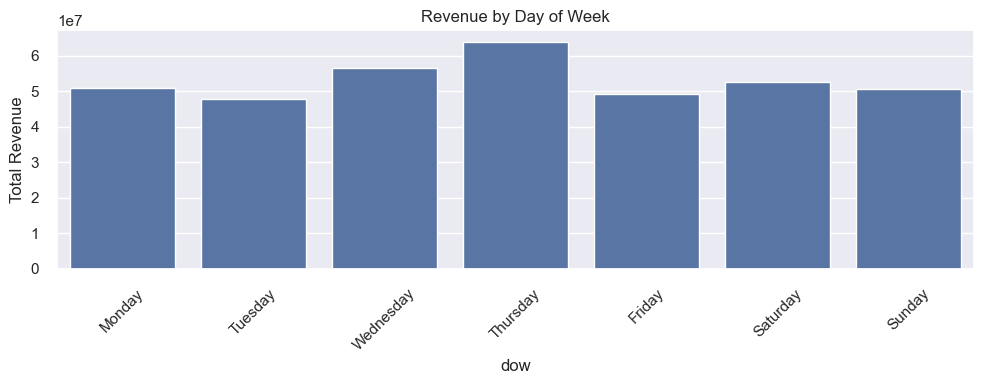

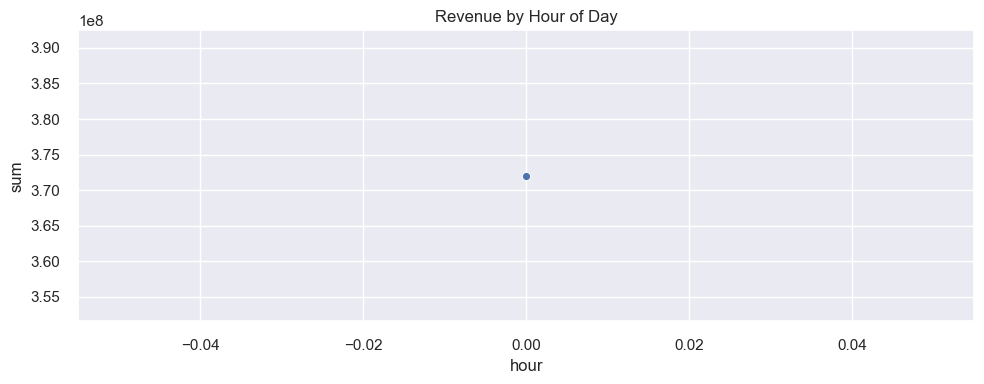

In [23]:
# Seasonality
dow = ts.groupby('dow')[use_value_col].agg(['sum','count','mean']).reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
display(dow)

plt.figure(figsize=(10,4))
sns.barplot(x=dow.index, y=dow['sum'])
plt.title('Revenue by Day of Week')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

# Hour of day (if present)
if 'hour' in ts.columns:
    hour = ts.groupby('hour')[use_value_col].agg(['sum','count','mean']).reset_index()
    plt.figure(figsize=(10,4))
    sns.lineplot(data=hour, x='hour', y='sum', marker='o')
    plt.title('Revenue by Hour of Day')
    plt.tight_layout()
    plt.show()


order_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,...,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,NaT
cohort_month,,,,,,,,,,,,,,,,,,,,,
2017-01,1.0,0.0,0.0,0.0,0.0,0.003,0.009,0.006,0.009,0.006,...,0.0,0.018,0.009,0.009,0.015,0.0,0.003,0.012,0.012,0.652
2017-02,NaN,inf,NaN,inf,NaN,inf,inf,NaN,NaN,NaN,...,NaN,inf,NaN,inf,inf,inf,inf,inf,inf,inf
2017-03,NaN,NaN,inf,inf,inf,inf,inf,inf,NaN,NaN,...,inf,inf,inf,inf,inf,inf,NaN,inf,inf,inf
2017-04,NaN,NaN,NaN,inf,inf,inf,inf,NaN,inf,inf,...,inf,inf,inf,inf,NaN,NaN,inf,inf,NaN,inf
2017-05,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,NaN,inf,inf,inf,inf,inf,inf
2017-06,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2017-07,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,NaN,inf
2017-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2017-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf


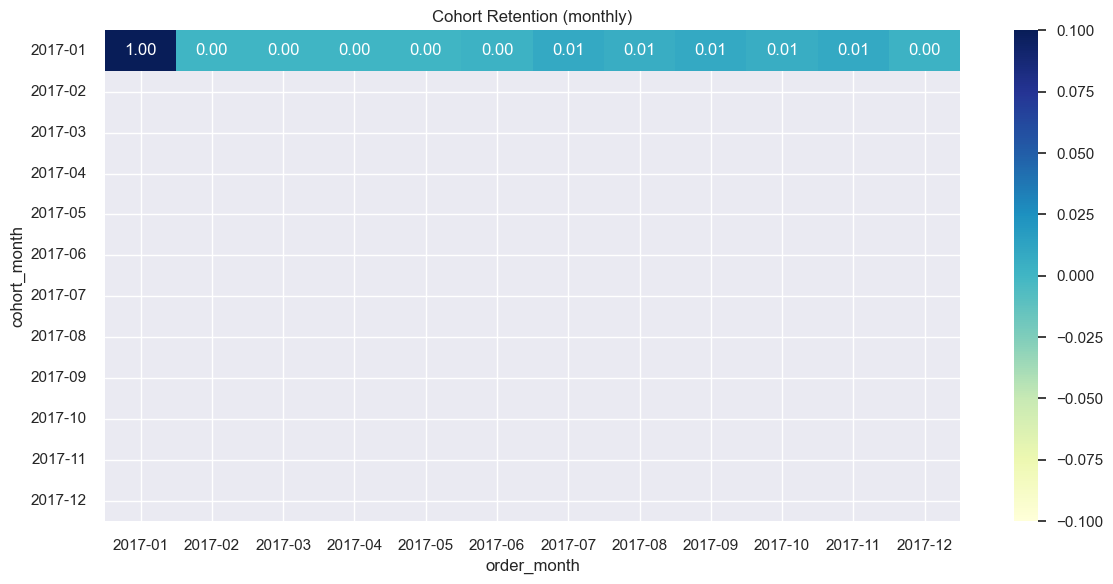

In [24]:
# Cohort analysis (monthly cohorts)
cohort_df = df.copy()
cohort_df['order_month'] = pd.to_datetime(cohort_df[date_col]).dt.to_period('M')
# first purchase month per user
first_month = cohort_df.groupby('user_id')['order_month'].min().reset_index()
first_month.columns = ['user_id','cohort_month']
cohort = cohort_df.merge(first_month, on='user_id')
cohort['cohort_month'] = cohort['cohort_month'].astype(str)
cohort['order_month'] = cohort['order_month'].astype(str)

cohort_counts = cohort.groupby(['cohort_month','order_month'])['user_id'].nunique().reset_index()
# pivot to retention matrix
retention = cohort_counts.pivot(index='cohort_month', columns='order_month', values='user_id').fillna(0)
# convert to percent of cohort size (first column)
cohort_sizes = retention.iloc[:,0]
retention_pct = retention.div(cohort_sizes, axis=0).round(3)
display(retention_pct.head(12))

# Heatmap for top 12 cohorts
plt.figure(figsize=(12,6))
sns.heatmap(retention_pct.iloc[:12, :12], annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cohort Retention (monthly)')
plt.tight_layout()
plt.show()


Missing values before imputation:
 user_id          0
recency      33447
frequency        0
monetary         0
dtype: int64

Missing values after imputation:
 user_id      0
recency      0
frequency    0
monetary     0
dtype: int64


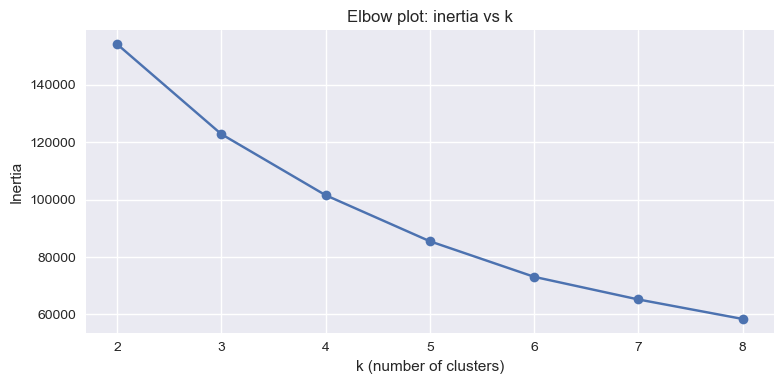

,cluster,users,recency_median,frequency_median,monetary_median
0,0,19875,616.0,2.0,6958.0
1,3,17755,429.0,3.0,6685.0
2,2,12266,970.0,2.0,3227.0
3,1,28033,616.0,1.0,296.0



Cluster summary with percentage of users:


,cluster,users,recency_median,frequency_median,monetary_median,pct_users
0,0,19875,616.0,2.0,6958.0,25.503984
1,3,17755,429.0,3.0,6685.0,22.783559
2,2,12266,970.0,2.0,3227.0,15.739968
3,1,28033,616.0,1.0,296.0,35.972488


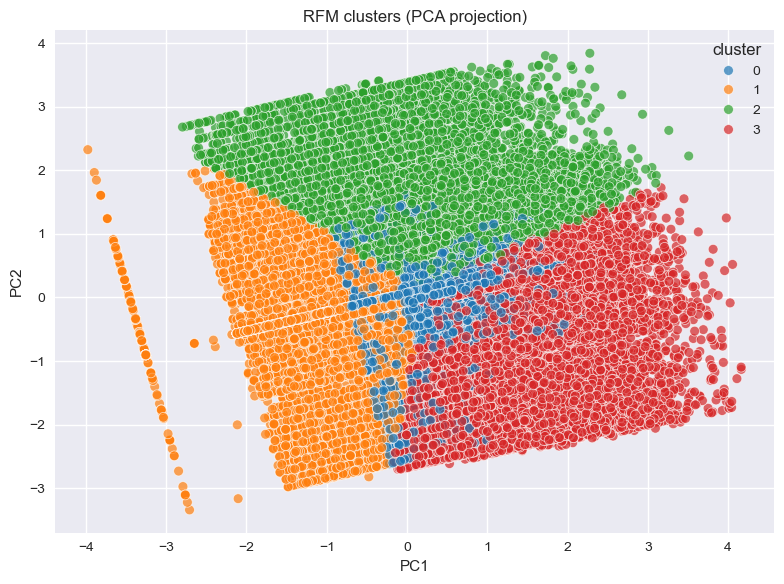


Sample of users with assigned segments:


,user_id,recency,frequency,monetary,cluster,segment
0,1,1091.0,2.0,1672.0,2,Potential
1,10,521.0,2.0,2773.0,0,VIP
2,1000,492.0,3.0,3611.0,3,Loyal
3,10000,616.0,1.0,74.0,1,LowValue
4,10001,547.0,4.0,12449.0,3,Loyal
5,10002,616.0,2.0,185.0,1,LowValue
6,10003,616.0,1.0,394.0,1,LowValue
7,10004,728.0,2.0,4297.0,0,VIP
8,10005,616.0,1.0,2028.0,0,VIP
9,10006,585.0,2.0,78.0,1,LowValue


In [25]:
# Robust RFM + KMeans clustering (handles NaNs, shows elbow, PCA viz)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme()
plt.style.use('seaborn-v0_8')

# ---- 1) Build RFM safely ----
# df, date_col and use_value_col are expected to exist from prior cells
df_rfm = df.copy()

# Ensure date column is datetime
df_rfm[date_col] = pd.to_datetime(df_rfm[date_col], errors='coerce')

# Snapshot date: next day after last order (handles if date_col has NaT)
snapshot_date = df_rfm[date_col].max()
if pd.isna(snapshot_date):
    raise ValueError("No valid dates found in date_col. Fix date parsing first.")
snapshot_date = snapshot_date + pd.Timedelta(days=1)

# Aggregate RFM
rfm = df_rfm.groupby('user_id').agg(
    recency_days = (date_col, lambda x: (snapshot_date - pd.to_datetime(x)).dt.days.min()),
    frequency = ('order_id', 'nunique'),
    monetary = (use_value_col, 'sum')
).reset_index()

# Ensure correct column names
rfm.columns = ['user_id', 'recency', 'frequency', 'monetary']

# Inspect missingness
print("Missing values before imputation:\n", rfm.isna().sum())

# ---- 2) Impute missing values ----
# We'll impute recency/frequency/monetary with median (robust)
imputer = SimpleImputer(strategy='median')
rfm_imputed_vals = imputer.fit_transform(rfm[['recency','frequency','monetary']])
rfm_imputed = pd.DataFrame(rfm_imputed_vals, columns=['recency','frequency','monetary'])
rfm[['recency','frequency','monetary']] = rfm_imputed[['recency','frequency','monetary']]

print("\nMissing values after imputation:\n", rfm.isna().sum())

# ---- 3) Transform: log for skewed features, then scale ----
rfm_trans = rfm.copy()
# frequency & monetary typically skewed -> log1p
rfm_trans['frequency_log'] = np.log1p(rfm_trans['frequency'])
rfm_trans['monetary_log'] = np.log1p(rfm_trans['monetary'])
# keep recency as-is (lower recency is better)
features = ['recency','frequency_log','monetary_log']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_trans[features])

# ---- 4) Elbow plot to choose k (visual aid) ----
inertia = []
K_range = range(2,9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow plot: inertia vs k')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- 5) Fit KMeans (default k=4) ----
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_scaled)
rfm['cluster'] = labels

# ---- 6) Cluster summary ----
cluster_summary = rfm.groupby('cluster').agg(
    users=('user_id','nunique'),
    recency_median=('recency','median'),
    frequency_median=('frequency','median'),
    monetary_median=('monetary','median')
).sort_values(by='monetary_median', ascending=False).reset_index()

display(cluster_summary)

# Add cluster sizes and percent of users
cluster_summary['pct_users'] = cluster_summary['users'] / cluster_summary['users'].sum() * 100
print("\nCluster summary with percentage of users:")
display(cluster_summary)

# ---- 7) PCA 2D visualization of clusters ----
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(pcs, columns=['pc1','pc2'])
pc_df['cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=pc_df, x='pc1', y='pc2', hue='cluster', palette='tab10', alpha=0.7, s=50)
plt.title('RFM clusters (PCA projection)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='cluster')
plt.tight_layout()
plt.show()

# ---- 8) Quick actionable labels (human-readable) ----
# We will tag clusters by monetary_median and frequency_median heuristics
summary = cluster_summary.copy()
summary = summary.sort_values(by='monetary_median', ascending=False).reset_index(drop=True)
summary['segment'] = ['VIP' if i==0 else 'Loyal' if i==1 else 'Potential' if i==2 else 'LowValue' for i in range(len(summary))]
# Map labels back to rfm
label_to_segment = dict(zip(summary['cluster'], summary['segment']))
rfm['segment'] = rfm['cluster'].map(label_to_segment)

print("\nSample of users with assigned segments:")
display(rfm[['user_id','recency','frequency','monetary','cluster','segment']].head(10))


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare features
model_df = df.copy()
model_df = model_df.dropna(subset=[date_col, use_value_col])
model_df['hour'] = pd.to_datetime(model_df[date_col]).dt.hour
model_df['dow'] = pd.to_datetime(model_df[date_col]).dt.day_name()

# Select available feature columns
feature_cols = []
if 'age' in model_df.columns: feature_cols.append('age')
if 'gender' in model_df.columns: feature_cols.append('gender')
if 'city' in model_df.columns: feature_cols.append('city')
if 'cuisine' in model_df.columns: feature_cols.append('cuisine')
feature_cols += ['hour','dow']  # Always include time-based features

# Target variable
y = model_df[use_value_col].values

# Separate numeric and categorical features
numeric_features = [c for c in feature_cols if model_df[c].dtype in [np.int64, np.float64] or c in ['age','hour']]
categorical_features = [c for c in feature_cols if c not in numeric_features]

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Full modeling pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train/test split
X = model_df[feature_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")


Model Performance:
MAE  = 9061.99
RMSE = 30162.14
R²   = -0.002


🔍 Top 15 Features Driving Order Value:


,Feature,Importance
0,age,0.501513
2,gender_Female,0.094075
3,gender_Male,0.091212
10,dow_Tuesday,0.057842
11,dow_Wednesday,0.055303
5,dow_Friday,0.053741
7,dow_Saturday,0.042124
6,dow_Monday,0.036799
9,dow_Thursday,0.034153
8,dow_Sunday,0.033238


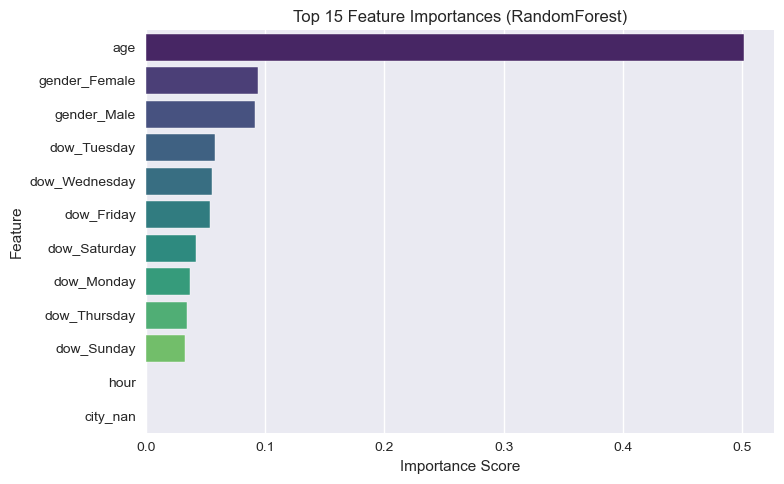

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure pipeline exists — if not, train it again
if 'pipeline' not in locals():
    raise NameError("⚠️ Model pipeline not found. Please run the ML model training cell first (the one that ends with MAE, RMSE, R2 scores).")

# Access OneHotEncoder and get feature names
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']

# Get feature names from the encoder
if hasattr(ohe, 'get_feature_names_out'):
    cat_feature_names = ohe.get_feature_names_out(pipeline.named_steps['preprocessor'].transformers_[1][2])
else:
    cat_feature_names = ohe.get_feature_names(pipeline.named_steps['preprocessor'].transformers_[1][2])

# Combine all feature names (numeric + categorical)
num_feature_names = pipeline.named_steps['preprocessor'].transformers_[0][2]
feature_names = list(num_feature_names) + list(cat_feature_names)

# Extract feature importances
importances = pipeline.named_steps['regressor'].feature_importances_
fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 15
top_fi = fi.head(15)

print("🔍 Top 15 Features Driving Order Value:")
display(top_fi)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=top_fi, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (RandomForest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
